<a href="https://colab.research.google.com/github/pujaroy280/DATA612/blob/main/DATA612_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: Content-Based and Collaborative Filtering**

Puja Roy

Summer 2026

### **Introduction**

This project is about implementing two collaborative filtering methods by utilizing the MovieLens 100K dataset:

• User-User Collaborative Filtering

• Item-Item Collaborative Filtering

The objective is to compare recommendation accuracy of the algorithms under different similarity measures and neighborhood sizes.


### **Part 1: Load Data & Run Recommendation Systems**

In [3]:
# Install the scikit-surprise library
!pip install scikit-surprise

# Import pandas for data manipulation and tables
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import the MovieLens dataset loader from Surprise
from surprise import Dataset

# Import Reader (not required for built-in MovieLens but commonly used)
from surprise import Reader

# Import KNNBasic collaborative filtering algorithm
from surprise import KNNBasic

# Import accuracy metrics such as RMSE
from surprise import accuracy

# Import function for splitting data into train and test sets
from surprise.model_selection import train_test_split

# Load the built-in MovieLens 100K dataset
data = Dataset.load_builtin('ml-100k')

# Split the dataset into 80% training and 20% testing data
trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

# Create an empty list to store model results
results = []

# Create a list containing model names and similarity configurations
configs = [

    # User-based collaborative filtering using cosine similarity
    (
        "User-User Cosine",
        {
            'name': 'cosine',
            'user_based': True
        }
    ),

    # User-based collaborative filtering using Pearson correlation
    (
        "User-User Pearson",
        {
            'name': 'pearson',
            'user_based': True
        }
    ),

    # Item-based collaborative filtering using cosine similarity
    (
        "Item-Item Cosine",
        {
            'name': 'cosine',
            'user_based': False
        }
    ),

    # Item-Based collaborative filtering using Pearson correlation
    (
        "Item-Item Pearson",
        {
            'name': 'pearson',
            'user_based': False
        }
    )
]

# Loop through each recommender configuration
for name, sim_options in configs:

    # Create the KNN recommender model
    algo = KNNBasic(

        # Set neighborhood size to 20 nearest neighbors
        k=20,

        # Apply the selected similarity configuration
        sim_options=sim_options
    )

    # Train the recommender on the training data
    algo.fit(trainset)

    # Generate predictions for all observations in the test set
    predictions = algo.test(testset)

    # Calculate RMSE for the predictions
    rmse = accuracy.rmse(
        predictions,
        verbose=False
    )

    # Save the algorithm name and RMSE score
    results.append(
        [
            name,
            rmse
        ]
    )

# Convert the results list into a DataFrame
results_df = pd.DataFrame(

    # Data source
    results,

    # Column names
    columns=[
        "Algorithm",
        "RMSE"
    ]
)

# Display the final results table
print(results_df)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
           Algorithm      RMSE
0   User-User Cosine  1.028382
1  User-User Pearson  1.022424
2   Item-Item Cosine  1.046763
3  Item-Item Pearson  1.064462


### **Part 2: Create the Graph**

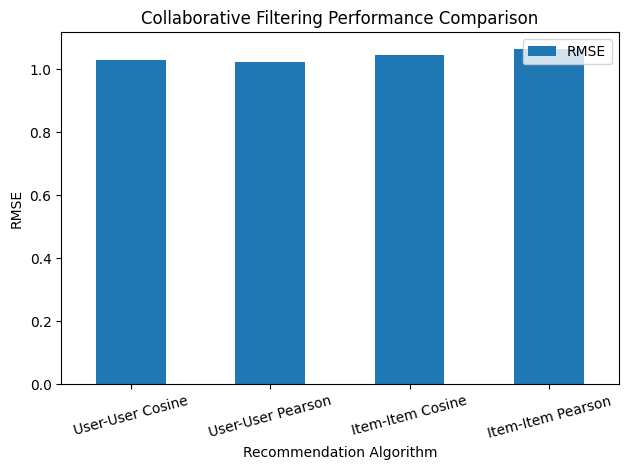

In [4]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a bar chart from the results DataFrame
results_df.plot(

    # Use algorithm names on the x-axis
    x='Algorithm',

    # Use RMSE values on the y-axis
    y='RMSE',

    # Display bars
    kind='bar'
)

# Label the y-axis
plt.ylabel("RMSE")

# Label the x-axis
plt.xlabel("Recommendation Algorithm")

# Add a chart title
plt.title("Collaborative Filtering Performance Comparison")

# Rotate labels for readability
plt.xticks(rotation=15)

# Adjust spacing automatically
plt.tight_layout()

# Display the graph
plt.show()

### **Part 3: Summary Statistics Table**

In [5]:
# Sort the results by RMSE from best to worst
ranked_results = results_df.sort_values(

    # Sort using RMSE values
    by="RMSE",

    # Smaller RMSE is better
    ascending=True
)

# Display ranked results
print(ranked_results)

           Algorithm      RMSE
1  User-User Pearson  1.022424
0   User-User Cosine  1.028382
2   Item-Item Cosine  1.046763
3  Item-Item Pearson  1.064462


### **Results**

The four collaborative filtering models were checked to see how well they worked. This was done by using Root Mean Squared Error. When Root Mean Squared Error is low it means the model is good at guessing ratings. Resutlts displayed that the User-User Collaborative Filtering model with Pearson correlation was the best. It had a Root Mean Squared Error of 1.022424 which suggests that its best for recommending suggestions. The User-User Collaborative Filtering model with Cosine similarity was okay but not as great at the User-User Collaborative Filtering model. The other two models, Item-Item Collaborative Filtering models did not do well. They had high Root Mean Squared Error values. This means they are not good at guessing ratings, for the MovieLens 100K dataset.

### **Recommendations**

I think the User-User Collaborative Filtering model with Pearson similarity is a choice for this dataset. It gave us a Root Mean Square Error value of 1.0224, which's really good.

The User-User Collaborative Filtering model did okay. To make it better we could try a things. For example we could use neighborhood sizes like 40 users or 60 users or 80 users to see what works best for the User-User Collaborative Filtering model.

We could also try matrix factorization methods. One type of matrix factorization is Singular Value Decomposition.

* We could check out Singular Value Decomposition. See if it fits our dataset well.

* We could also try types of matrix factorization to see what works best for us.

Another method we can apply is combining the User-User Collaborative Filtering model with content-based filtering since it might allow for the recommendations from the User-User Collaborative Filtering model to become more accurate.

The User-User Collaborative Filtering model, with Pearson similarity did well. That's why I think we should use the User-User Collaborative Filtering model for this dataset. The User-User Collaborative Filtering model is a choice because it worked well and gave us good results. The User-User Collaborative Filtering model seems to be an option.

### **Conclusion**

This purpose of this project was to utilize the MovieLens 100K dataset to implement 2 recommendation algorithms:

• User-User Collaborative Filtering

• Item-Item Collaborative Filtering

The models were compared using RMSE as the primary evaluation metric. Results showed that the User-User Collaborative Filtering with Pearson performed the best while Item-Item Collaborative Filtering with Pearson similarity produced the lowest accuracy. The results indicate that user-based collaborative filtering was more effective than item-based collaborative filtering for this dataset and project. Conducting this project was important since it demonstrates the significance of selecting appropriate similarity measures and recommendation strategies when developing recommender systems.